# Gold table exploration
Run all cells in the project Jupyter container. Reads existing gold Parquet outputs only.
Counts describe customer snapshots, not independent people. Labels describe loan outcomes.
Change the dates below to explore a smaller period. Ratios are diagnostics, not proof of errors.

In [1]:
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for base in [Path.cwd(), *Path.cwd().parents]
            for p in [base, base / 'Assignment 1'] if (p / 'datamart').exists())
START_DATE = None  # Example: '2023-01-01'
END_DATE = None    # Example: '2024-12-01'
RATIO_LOW, RATIO_HIGH = 0.5, 1.5  # Exploration thresholds; not cleaning rules
con = duckdb.connect()
tables = {}
for name, folder, pattern in [('labels', 'label_store', 'gold_label_store_*'),
        ('attributes', 'feature_store/fe_attr', 'gold_fe_attr_*'),
        ('financials', 'feature_store/fe_fin', 'gold_fe_fin_*'),
        ('clickstream', 'feature_store/fe_click', 'gold_fe_click_*')]:
    files = sorted(str(p) for p in (ROOT / 'datamart/gold' / folder).glob(pattern + '.parquet/part-*.parquet'))
    if not files:
        raise FileNotFoundError(f'No gold data for {folder}. Run main.py first.')
    frame = con.read_parquet(files, union_by_name=True).df()
    frame['snapshot_date'] = pd.to_datetime(frame['snapshot_date'])
    if START_DATE:
        frame = frame[frame.snapshot_date >= pd.Timestamp(START_DATE)]
    if END_DATE:
        frame = frame[frame.snapshot_date <= pd.Timestamp(END_DATE)]
    tables[name] = frame
labels, attr, fin, click = [tables[name] for name in ['labels', 'attributes', 'financials', 'clickstream']]
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.2})

## Table coverage and missing values
Duplicate keys are diagnostics: investigate before joining tables. Empty early clickstream
partitions have no rows because only activity strictly before the snapshot is included.

,table,rows,customers,columns,first_date,last_date,duplicate_key_rows
0,labels,12500,12500,5,2023-07-01,2025-07-01,0
1,attributes,12500,12500,6,2023-01-01,2025-01-01,0
2,financials,12500,12500,46,2023-01-01,2025-01-01,0
3,clickstream,305116,8974,24,2023-02-01,2025-11-01,0


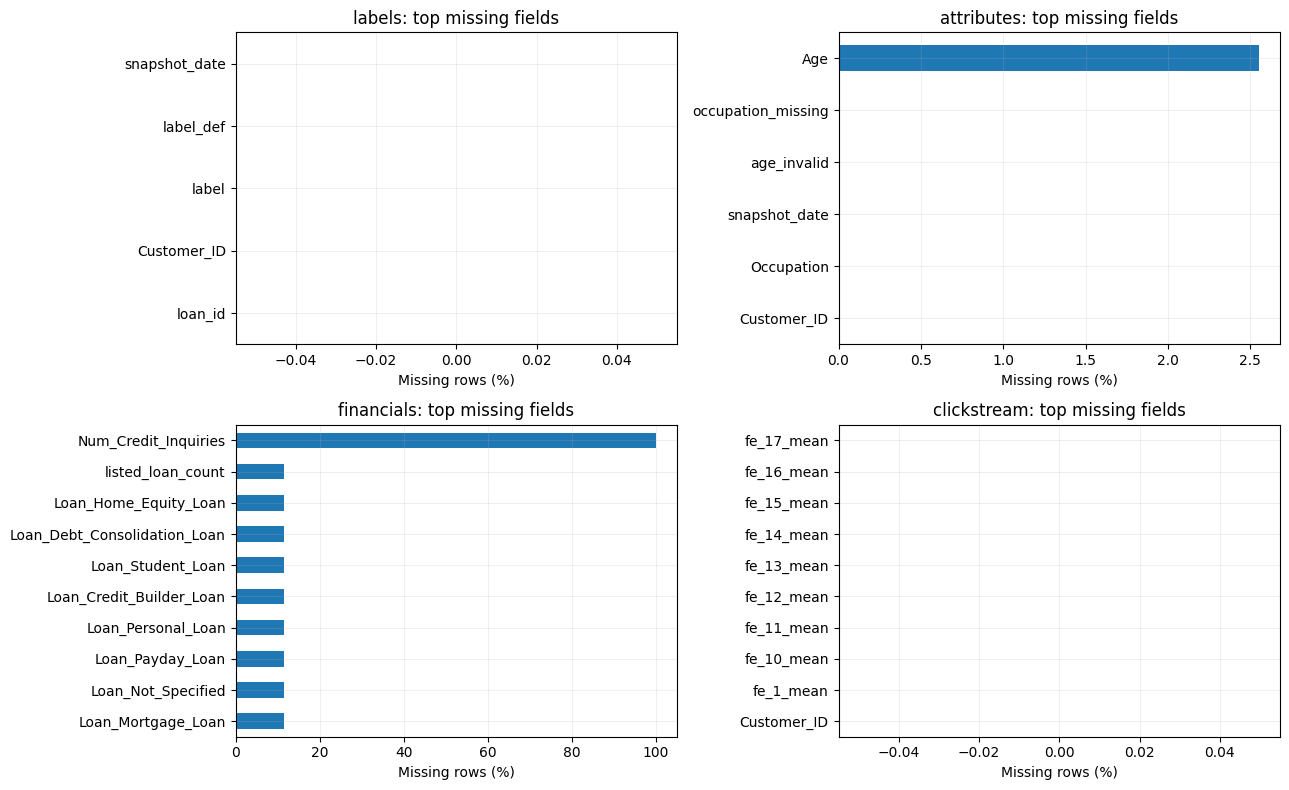

In [2]:
overview = []
for name, df in tables.items():
    keys = ['loan_id', 'snapshot_date'] if name == 'labels' else ['Customer_ID', 'snapshot_date']
    overview.append({'table': name, 'rows': len(df), 'customers': df.Customer_ID.nunique(),
                     'columns': len(df.columns), 'first_date': df.snapshot_date.min(),
                     'last_date': df.snapshot_date.max(), 'duplicate_key_rows': int(df.duplicated(keys).sum())})
display(pd.DataFrame(overview))
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (name, df) in zip(axes.flat, tables.items()):
    missing = df.isna().mean().mul(100).sort_values(ascending=False).head(10)
    missing.sort_values().plot.barh(ax=ax, title=f'{name}: top missing fields')
    ax.set_xlabel('Missing rows (%)')
plt.tight_layout()
plt.show()

## Monthly in-hand salary versus annual income
Ratio = 12 × Monthly_Inhand_Salary / Annual_Income. A ratio of 1 means exact agreement.
Gross/net definitions, deductions or additional income can explain differences; do not
automatically replace either field. Only finite, positive pairs are compared here.
The low/high thresholds are adjustable investigation flags, not validated business rules.

In [3]:
income = fin[['Customer_ID', 'snapshot_date', 'Annual_Income', 'Monthly_Inhand_Salary']].copy()
valid = (np.isfinite(income.Annual_Income) & np.isfinite(income.Monthly_Inhand_Salary)
         & income.Annual_Income.gt(0) & income.Monthly_Inhand_Salary.gt(0))
income = income.loc[valid].copy()
income['annualized_salary'] = income.Monthly_Inhand_Salary * 12
income['ratio'] = income.annualized_salary / income.Annual_Income
income['relative_gap'] = income.ratio - 1
income['extreme_ratio'] = (income.ratio < RATIO_LOW) | (income.ratio > RATIO_HIGH)
income_summary = pd.Series({
    'financial_rows': len(fin), 'valid_positive_pairs': len(income),
    'excluded_missing_nonpositive_or_nonfinite': len(fin) - len(income),
    'median_ratio': income.ratio.median(),
    'within_10_percent_count': int(income.ratio.between(0.9, 1.1).sum()),
    'within_10_percent_pct': income.ratio.between(0.9, 1.1).mean() * 100,
    'low_ratio_count': int((income.ratio < RATIO_LOW).sum()),
    'high_ratio_count': int((income.ratio > RATIO_HIGH).sum()),
    'extreme_ratio_pct': income.extreme_ratio.mean() * 100,
    'customers_with_extreme_ratio': income.loc[income.extreme_ratio, 'Customer_ID'].nunique(),
})
display(income_summary.to_frame('value'))
display(income[['Annual_Income', 'Monthly_Inhand_Salary', 'ratio']].describe(percentiles=[.01, .05, .5, .95, .99]))
display(income.sort_values('ratio').head(10))
display(income.sort_values('ratio', ascending=False).head(10))

,value
financial_rows,12500.000000
valid_positive_pairs,12500.000000
excluded_missing_nonpositive_or_nonfinite,0.000000
median_ratio,0.996526
within_10_percent_count,9637.000000
within_10_percent_pct,77.096000
low_ratio_count,114.000000
high_ratio_count,0.000000
extreme_ratio_pct,0.912000
customers_with_extreme_ratio,114.000000


,Annual_Income,Monthly_Inhand_Salary,ratio
count,1.250000e+04,12500.000000,12500.000000
mean,1.616206e+05,4188.592303,0.987502
std,1.297842e+06,3180.147611,0.135189
min,7.005930e+03,303.645417,0.000259
1%,7.542435e+03,531.867092,0.587792
5%,9.748734e+03,835.444271,0.821220
50%,3.757238e+04,3087.595000,0.996526
95%,1.343165e+05,10812.568750,1.158682
99%,1.788157e+05,13789.236200,1.301626
max,2.383470e+07,15204.633333,1.483346


,Customer_ID,snapshot_date,Annual_Income,Monthly_Inhand_Salary,annualized_salary,ratio,relative_gap,extreme_ratio
3764,CUS_0x5bba,2023-08-01,23713472.0,512.003333,6144.040000,0.000259,-0.999741,True
6175,CUS_0x5dfa,2024-01-01,23834698.0,684.157917,8209.895000,0.000344,-0.999656,True
2386,CUS_0x885f,2023-05-01,8006694.0,379.602917,4555.235000,0.000569,-0.999431,True
8293,CUS_0x8854,2024-05-01,15655612.0,768.976368,9227.716418,0.000589,-0.999411,True
10291,CUS_0x7ea1,2024-09-01,17872695.0,939.227083,11270.725000,0.000631,-0.999369,True
1051,CUS_0x1844,2023-03-01,11845938.0,636.715000,7640.580000,0.000645,-0.999355,True
1645,CUS_0x3a44,2023-04-01,12160681.0,685.868333,8230.420000,0.000677,-0.999323,True
532,CUS_0x1140,2023-02-01,14532812.0,914.150000,10969.800000,0.000755,-0.999245,True
836,CUS_0x81b8,2023-02-01,21964843.0,1553.835000,18646.020000,0.000849,-0.999151,True
3979,CUS_0xb042,2023-08-01,20368494.0,1460.257500,17523.090000,0.000860,-0.999140,True


,Customer_ID,snapshot_date,Annual_Income,Monthly_Inhand_Salary,annualized_salary,ratio,relative_gap,extreme_ratio
869,CUS_0x8df6,2023-02-01,7174.990,886.915833,10642.990,1.483346,0.483346,False
12070,CUS_0x3415,2025-01-01,7472.540,917.711667,11012.540,1.473734,0.473734,False
145,CUS_0x41b7,2023-01-01,7612.725,928.393750,11140.725,1.463435,0.463435,False
12345,CUS_0x93a7,2025-01-01,7414.145,903.845417,10846.145,1.462899,0.462899,False
6898,CUS_0xb303,2024-02-01,7169.585,867.465417,10409.585,1.451909,0.451909,False
1108,CUS_0x2d1c,2023-03-01,7596.060,919.005000,11028.060,1.451813,0.451813,False
1176,CUS_0x476d,2023-03-01,7710.840,927.570000,11130.840,1.443531,0.443531,False
8664,CUS_0x58aa,2024-06-01,7664.315,918.692917,11024.315,1.438395,0.438395,False
11531,CUS_0x2b09,2024-12-01,7630.570,910.880833,10930.570,1.432471,0.432471,False
620,CUS_0x33f9,2023-02-01,8052.790,961.065833,11532.790,1.432148,0.432148,False


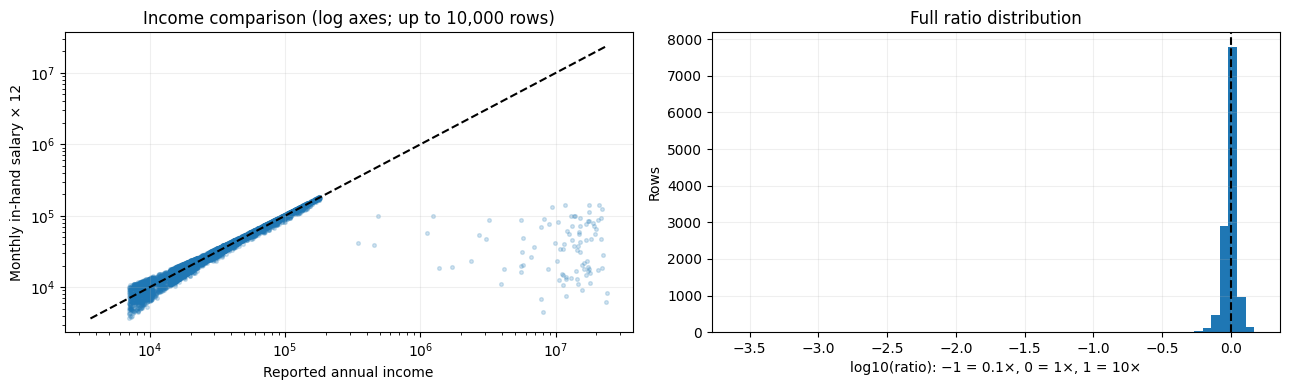

,rows,median_ratio,extreme_pct
snapshot_date,,,
2023-01-01,530,0.992038,0.754717
2023-02-01,501,0.998533,0.998004
2023-03-01,506,0.996295,0.988142
2023-04-01,510,0.999084,1.176471
2023-05-01,521,0.997244,0.959693
2023-06-01,517,0.996427,0.773694
2023-07-01,471,0.996501,0.849257
2023-08-01,481,0.991759,1.663202
2023-09-01,454,0.996357,1.762115


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sample = income.sample(min(10000, len(income)), random_state=42)
axes[0].scatter(sample.Annual_Income, sample.annualized_salary, s=7, alpha=.2)
if len(income):
    lower = min(income.Annual_Income.min(), income.annualized_salary.min())
    upper = max(income.Annual_Income.max(), income.annualized_salary.max())
    axes[0].plot([lower, upper], [lower, upper], '--', color='black', label='Equal amounts')
axes[0].set(xscale='log', yscale='log', xlabel='Reported annual income',
            ylabel='Monthly in-hand salary × 12', title='Income comparison (log axes; up to 10,000 rows)')
axes[1].hist(np.log10(income.ratio), bins=60)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='log10(ratio): −1 = 0.1×, 0 = 1×, 1 = 10×', ylabel='Rows', title='Full ratio distribution')
plt.tight_layout()
plt.show()
monthly_income = income.groupby('snapshot_date').agg(rows=('ratio', 'size'),
    median_ratio=('ratio', 'median'), extreme_pct=('extreme_ratio', lambda s: s.mean() * 100))
display(monthly_income)

## Investigate unusual income within a customer
These cross-date medians are EDA diagnostics only. They use the selected date range,
so must not be copied into model features or used to repair past records with future data.

In [5]:
observations = income.groupby('Customer_ID').size()
print('Customers with multiple financial snapshots:', int((observations > 1).sum()))
if not (observations > 1).any():
    print('Each customer has only one financial snapshot; within-customer history cannot validate these discrepancies.')
income['customer_median_income'] = income.groupby('Customer_ID').Annual_Income.transform('median')
income['income_vs_customer_median'] = income.Annual_Income / income.customer_median_income
display(income.loc[income.extreme_ratio].sort_values('income_vs_customer_median', ascending=False).head(20))
CUSTOMER_ID = income.sort_values('ratio').Customer_ID.iloc[0] if len(income) else None
# Replace CUSTOMER_ID with a customer you want to inspect.
display(income.loc[income.Customer_ID == CUSTOMER_ID].sort_values('snapshot_date'))

Customers with multiple financial snapshots: 0
Each customer has only one financial snapshot; within-customer history cannot validate these discrepancies.


,Customer_ID,snapshot_date,Annual_Income,Monthly_Inhand_Salary,annualized_salary,ratio,relative_gap,extreme_ratio,customer_median_income,income_vs_customer_median
18,CUS_0x1630,2023-01-01,17706148.0,6943.133333,83317.600,0.004706,-0.995294,True,17706148.0,1.0
292,CUS_0x78a7,2023-01-01,11777816.0,11636.443333,139637.320,0.011856,-0.988144,True,11777816.0,1.0
417,CUS_0xa488,2023-01-01,6755739.0,1167.429167,14009.150,0.002074,-0.997926,True,6755739.0,1.0
467,CUS_0xb67c,2023-01-01,3031039.0,3984.961667,47819.540,0.015777,-0.984223,True,3031039.0,1.0
532,CUS_0x1140,2023-02-01,14532812.0,914.150000,10969.800,0.000755,-0.999245,True,14532812.0,1.0
682,CUS_0x49ae,2023-02-01,10243765.0,1938.303333,23259.640,0.002271,-0.997729,True,10243765.0,1.0
713,CUS_0x532d,2023-02-01,22409880.0,2342.356667,28108.280,0.001254,-0.998746,True,22409880.0,1.0
835,CUS_0x8135,2023-02-01,344983.0,3451.874167,41422.490,0.120071,-0.879929,True,344983.0,1.0
836,CUS_0x81b8,2023-02-01,21964843.0,1553.835000,18646.020,0.000849,-0.999151,True,21964843.0,1.0
1051,CUS_0x1844,2023-03-01,11845938.0,636.715000,7640.580,0.000645,-0.999355,True,11845938.0,1.0


,Customer_ID,snapshot_date,Annual_Income,Monthly_Inhand_Salary,annualized_salary,ratio,relative_gap,extreme_ratio,customer_median_income,income_vs_customer_median
3764,CUS_0x5bba,2023-08-01,23713472.0,512.003333,6144.04,0.000259,-0.999741,True,23713472.0,1.0


## Financial features and quality flags
Histograms show the middle 98% of finite values for readability; the summary retains all values.
Missing ratios may reflect missing inputs or zero denominators. Negative disposable income is retained.

,EMI_to_Salary_Ratio,Debt_to_Income,Disposable_Income,Credit_History_Months
count,12500.000000,12500.000000,12500.000000,12500.000000
mean,0.619555,0.060092,2067.871199,224.608720
std,4.893254,0.087094,9286.044353,99.655759
min,0.000000,0.000002,-86755.692500,8.000000
1%,0.000000,0.000158,-53622.083572,21.000000
50%,0.026108,0.027842,2635.233499,222.000000
99%,20.093031,0.443533,12868.008058,400.000000
max,153.744129,0.683252,14805.770328,404.000000


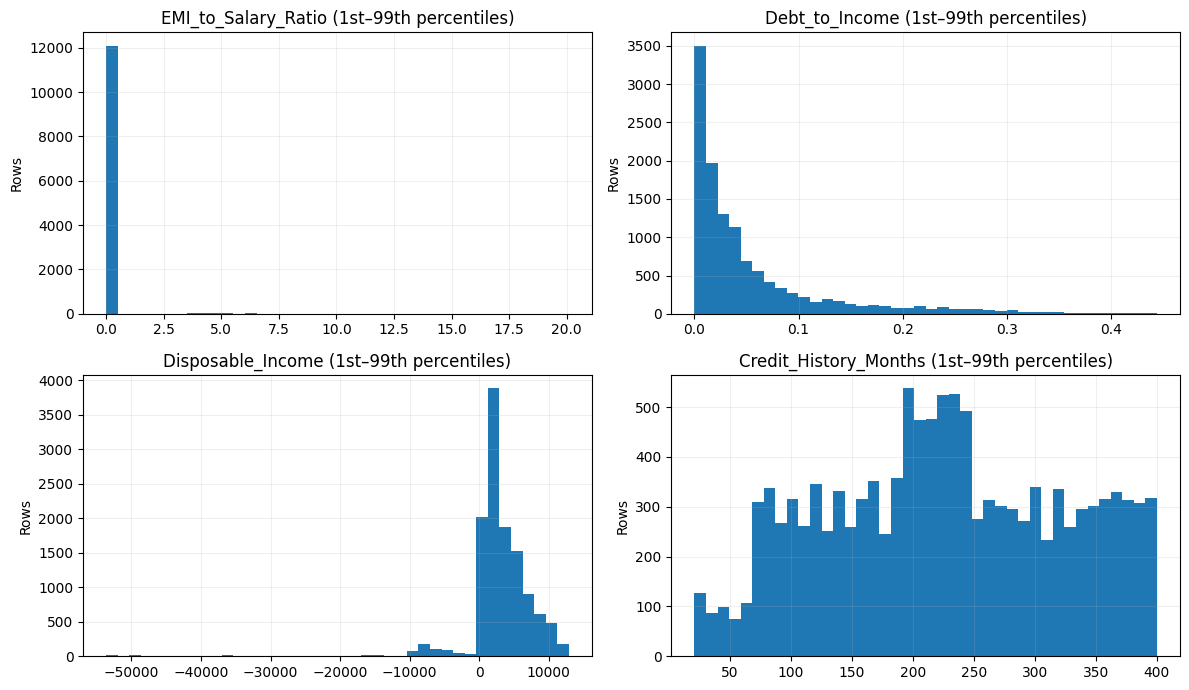

,flagged_pct
loan_count_suspicious,4.536
loan_types_missing,11.408
interest_rate_invalid,2.160


,rows
loan_count_status,
Match,10570
Missing loan list,1373
Invalid count,500
Mismatch,57


In [6]:
features = ['EMI_to_Salary_Ratio', 'Debt_to_Income', 'Disposable_Income', 'Credit_History_Months']
display(fin[features].describe(percentiles=[.01, .5, .99]))
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, column in zip(axes.flat, features):
    values = fin[column].replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = values.quantile([.01, .99]) if len(values) else (0, 0)
    ax.hist(values[values.between(lo, hi)], bins=40)
    ax.set(title=column + ' (1st–99th percentiles)', ylabel='Rows')
plt.tight_layout()
plt.show()
flags = [c for c in ['loan_count_suspicious', 'loan_types_missing', 'interest_rate_invalid'] if c in fin]
display(fin[flags].mean().mul(100).rename('flagged_pct').to_frame())
display(fin.loan_count_status.value_counts(dropna=False).rename('rows').to_frame())

## Customer attributes
These distributions count snapshots: a customer appearing in several months contributes several rows.

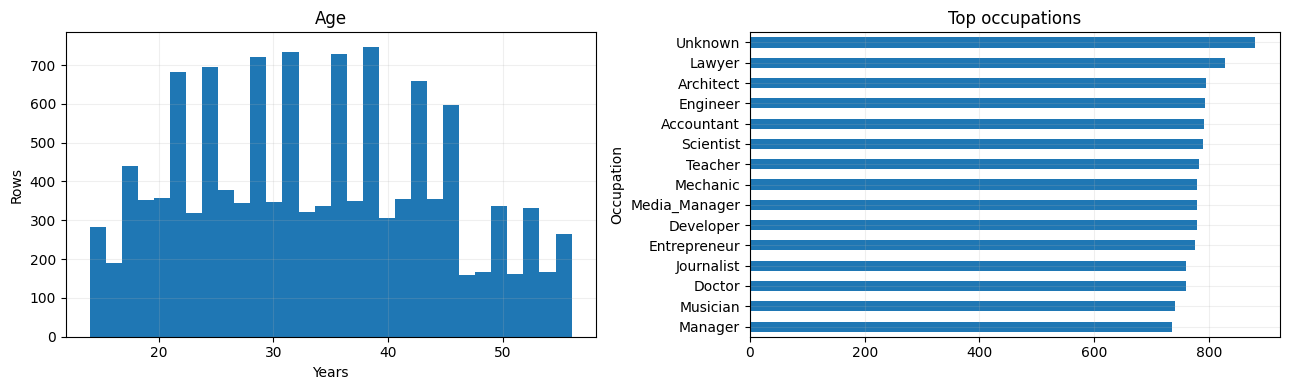

,flagged_pct
age_invalid,2.552
occupation_missing,7.040


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(attr.Age.dropna(), bins=30)
axes[0].set(title='Age', xlabel='Years', ylabel='Rows')
attr.Occupation.value_counts().head(15).sort_values().plot.barh(ax=axes[1], title='Top occupations')
plt.tight_layout()
plt.show()
display(attr[['age_invalid', 'occupation_missing']].mean().mul(100).rename('flagged_pct').to_frame())

## Clickstream coverage and feature distributions
has_clickstream is always 1 inside the click table; absent customers have no row there.
Coverage below uses attribute customer/date keys as the population and includes absent customers.
clickstream_days counts distinct observed dates; if source snapshots are monthly, it counts months observed.

,customers,coverage_pct
snapshot_date,,
2023-01-01,530,0.0
2023-02-01,501,100.0
2023-03-01,506,100.0
2023-04-01,510,100.0
2023-05-01,521,100.0
2023-06-01,517,100.0
2023-07-01,471,100.0
2023-08-01,481,100.0
2023-09-01,454,100.0


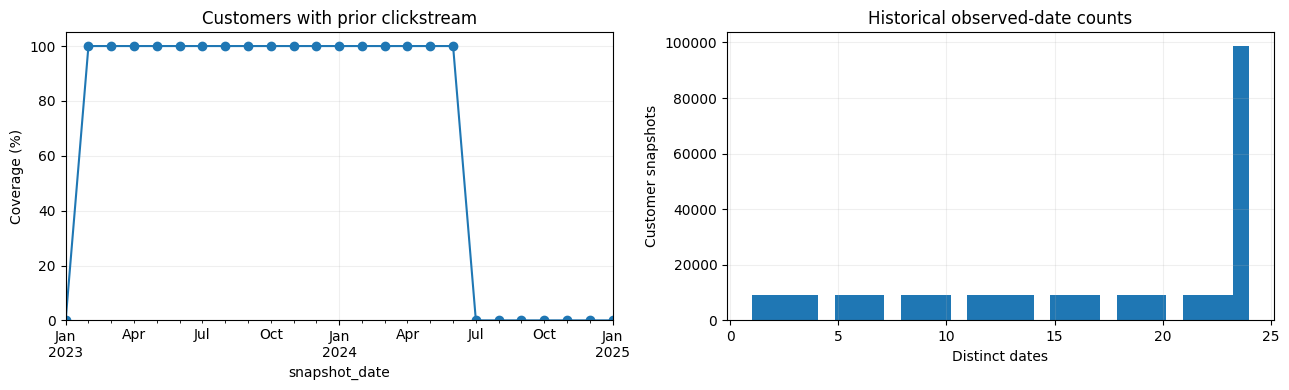

,fe_1_mean,fe_10_mean,fe_11_mean,fe_12_mean,fe_13_mean,fe_14_mean,fe_15_mean,fe_16_mean,fe_17_mean,fe_18_mean,fe_19_mean,fe_2_mean,fe_20_mean,fe_3_mean,fe_4_mean,fe_5_mean,fe_6_mean,fe_7_mean,fe_8_mean,fe_9_mean
count,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000,305116.000000
mean,101.787662,117.797512,99.686550,99.787612,100.559668,99.897305,99.718478,99.985162,99.903879,100.024052,100.301439,103.271700,100.075342,104.320308,105.716524,107.200764,103.522358,107.214038,110.851068,114.549086
std,35.197057,36.945579,35.338550,35.084663,35.263904,35.473902,35.734122,35.336138,35.591007,36.104494,36.100707,35.260413,36.230026,36.127977,36.422588,36.756621,35.321991,35.302449,35.780264,36.170884
min,-334.000000,-270.000000,-343.000000,-256.000000,-287.000000,-336.000000,-304.000000,-342.000000,-273.000000,-341.000000,-262.000000,-246.000000,-354.000000,-265.000000,-296.000000,-300.000000,-275.000000,-275.000000,-297.000000,-244.000000
25%,83.400000,98.000000,81.458333,81.750000,82.458333,81.791667,81.428571,82.083333,81.625000,81.550000,81.700000,84.868841,81.291667,85.400000,86.041667,87.166667,85.708333,88.791667,92.222222,95.333333
50%,101.571429,118.000000,99.666667,99.791667,100.541667,100.000000,99.500000,100.000000,100.000000,100.000000,100.315789,103.111111,100.083333,104.200000,105.409091,106.875000,103.291667,107.272727,111.000000,114.625000
75%,119.583333,137.666667,117.800000,117.562500,118.736842,118.076923,118.000000,118.041667,118.153846,118.708333,119.000000,121.625000,118.777778,123.100000,125.200000,126.857143,121.291667,125.500000,129.500000,133.916667
max,486.000000,472.000000,466.000000,519.000000,468.000000,463.000000,597.000000,471.000000,496.000000,462.000000,535.000000,472.000000,464.000000,490.000000,465.000000,570.000000,524.000000,505.000000,480.000000,477.000000


In [8]:
population = attr[['Customer_ID', 'snapshot_date']].drop_duplicates()
activity = click[['Customer_ID', 'snapshot_date']].drop_duplicates().assign(has_history=1)
coverage = population.merge(activity, on=['Customer_ID', 'snapshot_date'], how='left', validate='one_to_one')
coverage['has_history'] = coverage.has_history.fillna(0)
monthly_coverage = coverage.groupby('snapshot_date').agg(customers=('Customer_ID', 'size'),
    coverage_pct=('has_history', lambda s: s.mean() * 100))
display(monthly_coverage)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly_coverage.coverage_pct.plot(ax=axes[0], marker='o', title='Customers with prior clickstream')
axes[0].set_ylabel('Coverage (%)')
axes[0].set_ylim(0, 105)
axes[1].hist(click.clickstream_days.dropna(), bins=30)
axes[1].set(title='Historical observed-date counts', xlabel='Distinct dates', ylabel='Customer snapshots')
plt.tight_layout()
plt.show()
display(click[[c for c in click if c.startswith('fe_')]].describe())

## Labels over time
Label date is the outcome observation date at month-on-book 6, not the feature date.
Do not join labels to features on this date directly. Align features to the prediction/loan-start
date using loan_start_date in the gold label table, when preparing the model-training dataset.

,loans,default_rate
snapshot_date,,
2023-07-01,530,0.264151
2023-08-01,501,0.307385
2023-09-01,506,0.320158
2023-10-01,510,0.268627
2023-11-01,521,0.266795
2023-12-01,517,0.264990
2024-01-01,471,0.297240
2024-02-01,481,0.288981
2024-03-01,454,0.262115


,rows
label,
0,8898
1,3602


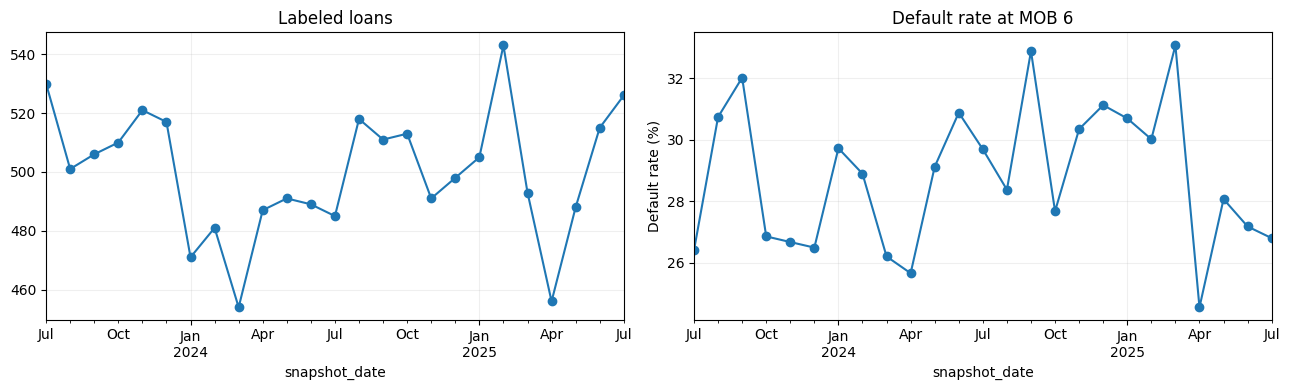

In [9]:
label_summary = labels.groupby('snapshot_date').agg(loans=('label', 'size'), default_rate=('label', 'mean'))
display(label_summary)
display(labels.label.value_counts(dropna=False).rename('rows').to_frame())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_summary.loans.plot(ax=axes[0], marker='o', title='Labeled loans')
label_summary.default_rate.mul(100).plot(ax=axes[1], marker='o', title='Default rate at MOB 6')
axes[1].set_ylabel('Default rate (%)')
plt.tight_layout()
plt.show()

## Combined features
One row per customer and feature snapshot date. Labels remain in the separate label store.
Join to loan outcomes at the application date when preparing model-training data.

In [10]:
joined_path = ROOT / 'datamart/gold/feature_store/gold_joined_features.parquet'
joined = con.read_parquet(str(joined_path / 'part-*.parquet')).df()
if START_DATE:
    joined = joined[joined.snapshot_date >= pd.Timestamp(START_DATE)]
if END_DATE:
    joined = joined[joined.snapshot_date <= pd.Timestamp(END_DATE)]
display(pd.Series({'feature_rows': len(joined),
    'duplicate_customer_date_keys': int(joined.duplicated(['Customer_ID', 'snapshot_date']).sum()),
    'missing_attributes': int(joined.has_attributes.eq(0).sum()),
    'missing_financials': int(joined.has_financials.eq(0).sum()),
    'without_clickstream': int(joined.has_clickstream.eq(0).sum())
}).to_frame('value'))
display(joined.head())

,value
feature_rows,12500
duplicate_customer_date_keys,0
missing_attributes,0
missing_financials,0
without_clickstream,4056


,Customer_ID,snapshot_date,Age,Occupation,age_invalid,occupation_missing,has_attributes,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,fe_20_mean,fe_3_mean,fe_4_mean,fe_5_mean,fe_6_mean,fe_7_mean,fe_8_mean,fe_9_mean,clickstream_days,has_clickstream
0,CUS_0x1013,2023-12-01,44,Mechanic,False,False,1,98620.98,7962.415000,3,...,111.454545,40.272727,97.818182,84.909091,137.181818,147.818182,97.818182,128.363636,11,1
1,CUS_0x1015,2023-08-01,27,Journalist,False,False,1,46951.02,3725.585000,7,...,165.714286,87.000000,85.000000,85.142857,97.714286,130.571429,132.428571,69.142857,7,1
2,CUS_0x1018,2023-11-01,15,Accountant,False,False,1,61194.81,5014.567500,7,...,68.300000,122.300000,152.100000,105.700000,62.800000,83.100000,93.700000,75.700000,10,1
3,CUS_0x102e,2024-04-01,26,Scientist,False,False,1,50807.44,4197.953333,8,...,109.066667,144.066667,146.933333,108.466667,163.533333,108.533333,115.333333,118.066667,15,1
4,CUS_0x1032,2023-08-01,40,Lawyer,False,False,1,60410.94,5274.245000,4,...,71.857143,68.857143,165.714286,44.142857,68.428571,76.285714,138.428571,135.142857,7,1
